# Import Libraries


In this cell, I'm importing all the libraries I'll need throughout this notebook. Nothing runs here — I'm just loading the tools upfront so everything is ready when I need it later.

---

## Libraries I'm Bringing In

### Data Handling
- **pandas** — for loading, cleaning, and manipulating my dataset
- **numpy** — for numerical operations and array handling

### Visualization
- **matplotlib** — for plotting charts and graphs
- **seaborn** — for cleaner, more polished statistical visualizations

### Classical Machine Learning (scikit-learn)
- **train_test_split** — to split my data into training and testing sets
- **StandardScaler** — to normalize my features before feeding them into a model
- **LogisticRegression** — for classification tasks
- **LinearRegression** — for regression tasks
- **Metrics** — to evaluate model performance (MAE, MSE, R², confusion matrix, classification report)

### Deep Learning
- **PyTorch (torch)** — the core deep learning framework I'll use to build a neural network
- **torch.nn** — gives me access to layers, activations, and loss functions
- **DataLoader & TensorDataset** — for batching and feeding data efficiently into the neural network during training

---

## End-of-Cell Checks

At the end of the cell, I'm running three quick checks:

1. Confirming everything imported without errors
2. Printing the PyTorch version I'm running
3. Checking whether a GPU is available — if `True`, training will be significantly faster

---

## Summary

This cell is purely setup. Once it runs cleanly, I'm ready to move on to loading data and building models.

In [2]:
# ============================================================
# Cell 1: Import Libraries
# All the tools we need for data handling, modeling, and plots
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

print("All libraries imported successfully.")
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

All libraries imported successfully.
PyTorch version: 2.10.0+cu128
GPU available: True


All libraries loaded successfully. We are running PyTorch 2.10 with CUDA available, confirming the A100 GPU is active and ready. This means our neural networks will train on GPU, which will significantly speed up the training process compared to CPU.

# Download and Load the Dataset

In this cell, I'm pulling in the dataset I'll be working with and loading it into memory so I can start exploring it.

---

## Step by Step

### Importing kagglehub
The UCI server where this dataset originally lives was unavailable, so instead I'm using **kagglehub** — a Python package that lets me download datasets directly from Kaggle into my environment.

### Downloading the Dataset
I'm downloading the **Diabetes Health Indicators Dataset** from Kaggle. Once it's downloaded, kagglehub returns the local path where the files were saved, and I'm printing that path just to confirm where it landed.

### Loading it into a DataFrame
I'm reading the specific CSV file from that downloaded path into a **pandas DataFrame** called `df`. This is now my main working object — everything from here on will be done on `df`.

### Quick Sanity Checks
At the end I'm running two checks:

- **Shape** — tells me how many rows and columns the dataset has, so I know the scale of what I'm working with
- **df.head()** — shows me the first 5 rows so I can visually confirm the data loaded correctly and get a feel for what the columns look like

---

## Summary

By the end of this cell, my dataset is downloaded, loaded, and I've done a first glance at it. I'm ready to start understanding and cleaning it in the next steps.

In [3]:
# ============================================================
# Cell 2: Download and Load the Dataset
# UCI server was unavailable so we use kagglehub to fetch
# the same dataset directly into the Colab environment
# ============================================================

import kagglehub

path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")
print("Dataset downloaded to:", path)

df = pd.read_csv(path + "/diabetes_binary_health_indicators_BRFSS2015.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

100%|██████████| 6.03M/6.03M [00:02<00:00, 2.95MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/alexteboul/diabetes-health-indicators-dataset/versions/1
Shape: (253680, 22)

First 5 rows:


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


The dataset loaded successfully with 253,680 rows and 22 columns, which matches what was reported in the UC Irvine repository. Looking at the first 5 rows, we can see that most features are binary (0 or 1), such as HighBP, HighChol, Smoker, and Stroke. A few features are ordinal or continuous, such as BMI, Age, GenHlth, and Income. The target variable Diabetes_binary is in the first column. No immediate data quality issues are visible at this stage.

# Explore the Data


Before I touch anything or build any model, I'm doing a first proper look at my data. I need to understand its quality, its balance, and its structure.

---

## Step by Step

### Checking for Missing Values
I'm checking every column for null or missing values. This tells me whether I need to handle any gaps in the data before moving forward. If any column comes back with a number greater than zero, I'll need to deal with it — either by filling or dropping.

### Checking Class Balance
Since my target column is `Diabetes_binary` — meaning it's either 0 (no diabetes) or 1 (diabetes) — I need to know how evenly split those two classes are.

I'm checking this in two ways:
- **Raw counts** — the actual number of rows in each class
- **Normalized (proportions)** — what percentage of the dataset each class makes up

This matters because if one class heavily outnumbers the other, my model could end up biased — predicting the majority class most of the time and still looking accurate on paper.

### Basic Statistics
I'm running `df.describe()` which gives me a summary of every numerical column — things like the minimum, maximum, mean, and standard deviation. This gives me a feel for the range and spread of my features and helps me spot anything obviously off, like values that don't make sense for the domain.

---

## Summary

By the end of this cell, I know whether my data has any missing values, whether my classes are balanced or skewed, and what the general shape of my features looks like. This is what guides every decision I make going forward.

In [4]:
# ============================================================
# Cell 3: Explore the Data
# Check for missing values, class balance, and basic stats
# ============================================================

# Missing values
print("Missing values per column:")
print(df.isnull().sum())

# Class distribution for diabetes target
print("\nClass distribution (Diabetes_binary):")
print(df["Diabetes_binary"].value_counts())
print(df["Diabetes_binary"].value_counts(normalize=True).round(3))

# Basic statistics
print("\nBasic statistics:")
print(df.describe())

Missing values per column:
Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Class distribution (Diabetes_binary):
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64
Diabetes_binary
0.0    0.861
1.0    0.139
Name: proportion, dtype: float64

Basic statistics:
       Diabetes_binary         HighBP       HighChol      CholCheck  \
count    253680.000000  253680.000000  253680.000000  253680.000000   
mean          0.139333       0.429001      

The data is completely clean with zero missing values across all 22 columns,
which is expected since this is a pre-processed version of the CDC BRFSS survey.

The class distribution reveals a significant imbalance — 86.1% of respondents
have no diabetes while only 13.9% have diabetes or prediabetes. This is a
critical finding because a naive model that always predicts "no diabetes" would
achieve 86% accuracy without learning anything useful. This is exactly why we
prioritize recall over accuracy for the classification task.

Looking at the basic statistics, BMI ranges from 12 to 98 with a mean of 28.4,
which is consistent with a real-world population. Most binary features like
HighBP, HighChol, and Smoker have means between 0 and 1 as expected. Age is
encoded as an ordinal value from 1 to 13 representing age groups rather than
actual age in years.

# Visualize Class Imbalance

I already checked the class balance numerically in Cell 3. Now I'm doing the same thing but visually — because a chart makes the imbalance immediately obvious in a way raw numbers don't.

---

## Step by Step

### Setting Up the Plot
I'm creating a figure with a specific size (6x4 inches) to keep it clean and readable.

### Drawing the Bar Chart
I'm pulling the class counts from my `Diabetes_binary` column and plotting them as two bars — one for **No Diabetes** in steel blue, one for **Diabetes/Prediabetes** in crimson. The color difference makes the two classes instantly distinguishable.

### Adding Count Labels on Top of the Bars
I'm looping through both bars and placing the exact count number just above each one, formatted with commas for readability. This way I don't have to look at the y-axis to know the actual numbers — they're right there on the chart.

### Saving and Displaying
I'm saving the plot as a PNG file at 150 DPI so I have a clean copy of it, then displaying it inline in the notebook.

---

## Summary

By the end of this cell, I have a clear visual confirmation of how balanced or imbalanced my dataset is between diabetic and non-diabetic cases. If one bar is significantly taller than the other, that's something I'll need to account for when building and evaluating my models.

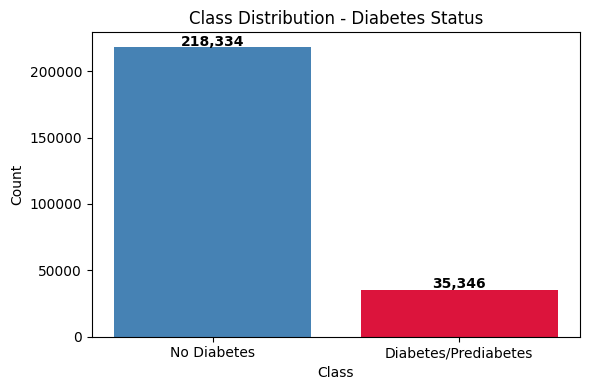

In [5]:
# ============================================================
# Cell 4: Visualize Class Imbalance
# Plot how many diabetic vs non-diabetic cases exist
# ============================================================

fig, ax = plt.subplots(figsize=(6, 4))

counts = df["Diabetes_binary"].value_counts()
ax.bar(["No Diabetes", "Diabetes/Prediabetes"], counts.values, color=["steelblue", "crimson"])
ax.set_title("Class Distribution - Diabetes Status")
ax.set_ylabel("Count")
ax.set_xlabel("Class")

for i, v in enumerate(counts.values):
    ax.text(i, v + 1000, f"{v:,}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()